In [2]:
import pandas as pd
import os
import pickle

In [11]:
# pickle load
# with open('./Actor_Clustering_n_3.pkl', 'rb') as f:
with open('./vector_df_kiwi.pkl', 'rb') as f:
    df = pickle.load(f)
   
df.head(5)

,Title,Date,Contents,re_review,tagged_review,vector,cluster
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,[장보기],"[-0.09933971, 0.07865631, -0.2573385, 0.077373...",1
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가, 딸, 기숙, 생활, 글, 올라오, 보, 고등, 생활, 힘들...","[-0.6199621, 0.50224173, -2.9589982, 0.5003893...",1
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋, 트렌디, 식재료, 많...","[-1.3436376, -1.5444121, -0.7325776, 0.1268179...",1
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤, 이유, 배달, 시키, 먹, 카드, 나오, 건강, 좋, 쉬, 되, 식비, 아...","[-0.06928706, 0.35859433, 0.161952, -1.426304,...",1
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 달, 간, 같, 마트, 근처, 홈플, 있, 최근, 행사, 상품, 좋, 괜찮...","[-0.23992725, -0.01749745, -0.62112886, 0.2107...",1


In [12]:
df_v = df[['vector', 'cluster']]
df_v

,vector,cluster
0,"[-0.09933971, 0.07865631, -0.2573385, 0.077373...",1
1,"[-0.6199621, 0.50224173, -2.9589982, 0.5003893...",1
2,"[-1.3436376, -1.5444121, -0.7325776, 0.1268179...",1
3,"[-0.06928706, 0.35859433, 0.161952, -1.426304,...",1
4,"[-0.23992725, -0.01749745, -0.62112886, 0.2107...",1
...,...,...
40481,"[-0.03328519, -0.85218066, -1.2653462, 0.14012...",1
40482,"[-1.6537082, -0.7218035, -2.6299286, -0.049720...",1
40483,"[-1.1066924, -1.3297558, -0.9958204, -0.305690...",1
40484,"[-0.64154005, 0.111185715, -1.0465375, -0.3496...",1


In [13]:
import numpy as np
from sklearn.decomposition import PCA

# 1) vector 컬럼을 (n_samples, 300) 행렬로 만들기
X = np.vstack(df_v['vector'].values)   # shape: (N, 300)

# 2) cluster 라벨
labels = df_v['cluster'].values        # shape: (N,)

# 3) PCA로 2차원으로 축소
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)           # shape: (N, 2)

# 4) 결과를 df_v에 붙여두면 나중에 분석하기 편함
df_v['pca1'] = X_pca[:, 0]
df_v['pca2'] = X_pca[:, 1]

C:\Users\4253\AppData\Local\Temp\ipykernel_30036\1087694513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca1'] = X_pca[:, 0]
C:\Users\4253\AppData\Local\Temp\ipykernel_30036\1087694513.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_v['pca2'] = X_pca[:, 1]


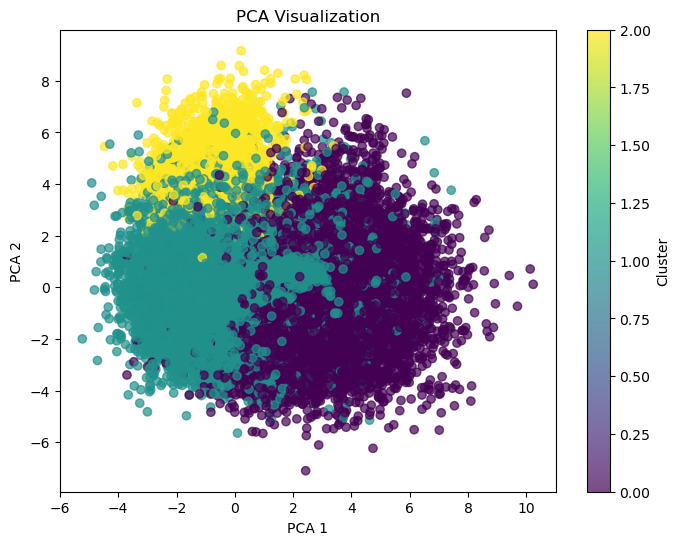

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_v['pca1'], df_v['pca2'],
                      c=df_v['cluster'], alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Visualization")

cbar = plt.colorbar(scatter)
cbar.set_label("Cluster")

plt.show()